## Bloque 3 · NLP y modelo pre-entrenado
**Dataset:** Reseñas de hoteles — Big_AHR.csv  
**Variable de texto:** `review_text`  
**Variable objetivo:** `label` (0=negativo, 1=positivo, 3=regular → remapeado a 0,1,2)  
**Estudiante:** Valentina Muñoz Palma  
**Curso:** Machine Learning con PySpark y Docker · 2026-I

## cargar librerías

In [1]:
!pip install transformers pysentimiento torch -q
!pip install langdetect -q

In [2]:
# ============================================================
# cargar librerias
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, size, explode, count, desc, avg
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.types import ArrayType, StructType, StructField, StringType, FloatType
from pysentimiento import create_analyzer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


# Iniciar sesión de Spark

In [3]:
# ============================================================
# sesion de spark
# ============================================================
spark = SparkSession.builder \
    .appName("Bloque3_NLP_ValentinaMunoz") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Sesión de Spark activa.")

Sesión de Spark activa.


### Tarea 21 · Cargar el corpus

In [4]:
# ============================================================
# Carga del dataset de reseñas de hoteles
# ============================================================
df_raw = spark.read.csv(
    "../datos/archive/Big_AHR.csv",
    header=True,
    inferSchema=True,
    quote='"',
    escape='"'     
)

print(f"Total de registros : {df_raw.count():,}")
print(f"Total de columnas  : {len(df_raw.columns)}")
print(f"\nColumnas disponibles: {df_raw.columns}")
df_raw.show(3, truncate=80)

Total de registros : 19,993
Total de columnas  : 7

Columnas disponibles: ['_c0', 'title', 'rating', 'review_text', 'location', 'hotel', 'label']
+---+---------------------------+------+--------------------------------------------------------------------------------+-------------------------------------+--------------------+-----+
|_c0|                      title|rating|                                                                     review_text|                             location|               hotel|label|
+---+---------------------------+------+--------------------------------------------------------------------------------+-------------------------------------+--------------------+-----+
|  0|Excelente y personal amable|     5|Un hotel muy bueno.  El personal fue muy amable y profesional. Nos gustaban d...|Seville_Province_of_Seville_Andalucia|H10_Casa_de_la_Plata|    1|
|  1|                   Céntrico|     4|Muy buen hotel al nivel de lo esperado, habitación junior suite, n

In [5]:
# ============================================================
# Seleccionar solo las columnas relevantes y remapear label
# label original: 0=negativo, 1=positivo, 3=regular
# label remapeado: 0=negativo, 1=positivo, 2=regular
# ============================================================
df = df_raw.select(
    col("review_text"),
    col("hotel"),
    col("label").cast("integer").alias("label_orig")
).withColumn(
    "label",
    F.when(col("label_orig") == 0, 0)
     .when(col("label_orig") == 1, 1)
     .when(col("label_orig") == 3, 2)
     .otherwise(None)
).filter(
    col("review_text").isNotNull() & col("label").isNotNull()
)

print(f"Registros tras limpieza: {df.count():,}")
print("\n--- Distribución de clases (remapeadas) ---")
total = df.count()
df.groupBy("label").count() \
  .withColumn("sentimiento", 
    F.when(col("label")==0, "Negativo")
     .when(col("label")==1, "Positivo")
     .otherwise("Regular")) \
  .withColumn("%", F.round(col("count")/total*100, 2)) \
  .orderBy("label").show()

Registros tras limpieza: 16,352

--- Distribución de clases (remapeadas) ---
+-----+-----+-----------+-----+
|label|count|sentimiento|    %|
+-----+-----+-----------+-----+
|    0| 2160|   Negativo|13.21|
|    1|12207|   Positivo|74.65|
|    2| 1985|    Regular|12.14|
+-----+-----+-----------+-----+



### Tarea 22 · Tokenización con RegexTokenizer y filtrado de stop words en español


In [6]:
# ============================================================
# RegexTokenizer con soporte para caracteres acentuados en español
# El patron [^a-záéíóúüñA-ZÁÉÍÓÚÜÑ]+ captura SOLO letras españolas
# y descarta todo lo demas (puntuacion, numeros, simbolos)
# ============================================================
tokenizer = RegexTokenizer(
    inputCol="review_text",
    outputCol="tokens_raw",
    pattern="[^a-záéíóúüñA-ZÁÉÍÓÚÜÑ]+",
    minTokenLength=2,
    toLowercase=True
)

In [7]:
# ============================================================
# Necesarias las stop words en otros idiomas ya que a pesar de
# ser un corpus en "español" hay opiniones en ingles y otros idiomas
#y si no se quitan antes apareceran como hapax
# ============================================================
stop_words_es = StopWordsRemover.loadDefaultStopWords("spanish")
stop_words_en = StopWordsRemover.loadDefaultStopWords("english")
stop_words_de = StopWordsRemover.loadDefaultStopWords("german")
stop_words_nl = StopWordsRemover.loadDefaultStopWords("dutch")
stop_words_it = StopWordsRemover.loadDefaultStopWords("italian")
stop_words_fr = StopWordsRemover.loadDefaultStopWords("french")

stop_words_combinadas = list(set(
    stop_words_es + stop_words_en + stop_words_de +
    stop_words_nl + stop_words_it + stop_words_fr
))

remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens",
    stopWords=stop_words_combinadas
)

print(f"Stop words combinadas: {len(stop_words_combinadas):,} palabras")
# Aplicar tokenización y remoción en secuencia
df_tokens = tokenizer.transform(df)
df_tokens = remover.transform(df_tokens)

print(f"\nEjemplo de primeras 3 reseñas tokenizadas:\n")
df_tokens.select("review_text", "tokens_raw", "tokens").show(3, truncate=60)

Stop words combinadas: 1,173 palabras

Ejemplo de primeras 3 reseñas tokenizadas:

+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+
|                                                 review_text|                                                  tokens_raw|                                                      tokens|
+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+
|Un hotel muy bueno.  El personal fue muy amable y profesi...|[un, hotel, muy, bueno, el, personal, fue, muy, amable, p...|[hotel, bueno, personal, amable, profesional, gustaban, d...|
|Muy buen hotel al nivel de lo esperado, habitación junior...|[muy, buen, hotel, al, nivel, de, lo, esperado, habitació...|[buen, hotel, nivel, esperado, habitación, junior, sui

### Limpieza del corpus: duplicados y reseñas vacías

In [8]:
# ============================================================
# DIAGNOSTICO 1: reseñas que quedaron vacias tras stop words
# ============================================================
df_vacias = df_tokens.filter(size("tokens") == 0)
print(f"Reseñas vacías tras stop words: {df_vacias.count()}")
print("\n--- Reseñas vacías (texto original) ---")
df_vacias.select("review_text", "tokens_raw", "label").show(5, truncate=80)

Reseñas vacías tras stop words: 4

--- Reseñas vacías (texto original) ---
+--------------------------------------------------------------------------------+----------+-----+
|                                                                     review_text|tokens_raw|label|
+--------------------------------------------------------------------------------+----------+-----+
|Отель находится не слишком далеко от пляжа, что удобно, также несложно добрат...|        []|    1|
|Отель находится не слишком далеко от пляжа, что удобно, также несложно добрат...|        []|    1|
|Отель находится не слишком далеко от пляжа, что удобно, также несложно добрат...|        []|    1|
|Отель находится не слишком далеко от пляжа, что удобно, также несложно добрат...|        []|    1|
+--------------------------------------------------------------------------------+----------+-----+



In [9]:
# ============================================================
# DIAGNOSTICO 2: duplicados exactos
# ============================================================
total       = df_tokens.count()
unicos      = df_tokens.dropDuplicates(["review_text"]).count()
duplicados  = total - unicos

print(f"\nTotal de registros    : {total:,}")
print(f"Registros unicos      : {unicos:,}")
print(f"Registros duplicados  : {duplicados:,}")
print(f"Porcentaje duplicados : {duplicados/total*100:.2f}%")

print("\n--- Ejemplos de reseñas más repetidas ---")
df_tokens.groupBy("review_text").count() \
         .filter(col("count") > 1) \
         .orderBy(desc("count")) \
         .select("review_text", "count") \
         .show(5, truncate=80)


Total de registros    : 16,352
Registros unicos      : 11,537
Registros duplicados  : 4,815
Porcentaje duplicados : 29.45%

--- Ejemplos de reseñas más repetidas ---
+--------------------------------------------------------------------------------+-----+
|                                                                     review_text|count|
+--------------------------------------------------------------------------------+-----+
|Magnífica acogida y atención. Trato inmejorable. Muy atentos durante la estan...|   16|
|Estuve alojado durante 3 noches, las habitaciones me parecieron bastante mode...|   16|
|El Hotel Sierra de Huesa tiene una ubicación excelente, muy cerca de la Cueva...|   16|
|Está muy bien ubicado, en el mismo centro de Quesada, al lado del Bar Capri, ...|   16|
|No se puede criticar la ubicación dada el hostal está en el centro de la ciud...|   12|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows



**Decisión de limpieza:** Se encontraron 4 reseñas en ruso que el tokenizador no pudo procesar (quedaron vacias) y 4,815 registros duplicados (29.45% del corpus). Se eliminan ambos antes del análisis para evitar sesgo en el TF-IDF y los modelos.

In [10]:
# ============================================================
# Eliminar duplicados y reseñas vacias
# El orden importa: primero duplicados, luego vacios
# ============================================================
df_tokens = df_tokens.dropDuplicates(["review_text"]) \
                     .filter(size("tokens") > 0)

total_final = df_tokens.count()
print(f"Corpus final: {total_final:,} reseñas únicas en español")

print("\n--- Distribución de clases tras limpieza ---")
df_tokens.groupBy("label").count() \
  .withColumn("sentimiento",
    F.when(col("label")==0, "Negativo")
     .when(col("label")==1, "Positivo")
     .otherwise("Regular")) \
  .withColumn("%", F.round(col("count")/total_final*100, 2)) \
  .orderBy("label").show()

Corpus final: 11,536 reseñas únicas en español

--- Distribución de clases tras limpieza ---
+-----+-----+-----------+-----+
|label|count|sentimiento|    %|
+-----+-----+-----------+-----+
|    0| 1553|   Negativo|13.46|
|    1| 8529|   Positivo|73.93|
|    2| 1454|    Regular| 12.6|
+-----+-----+-----------+-----+



In [11]:
# ============================================================
# Detectar reseñas en idiomas distintos al español
# Usamos langdetect para identificar el idioma de cada reseña
# ============================================================
from langdetect import detect, LangDetectException

def detectar_idioma(texto):
    try:
        return detect(texto)
    except LangDetectException:
        return "desconocido"

# Aplicar sobre una muestra primero para ver la magnitud
pd_idiomas = df_tokens.select("review_text", "label").limit(500).toPandas()
pd_idiomas["idioma"] = pd_idiomas["review_text"].apply(detectar_idioma)

print("--- Distribución de idiomas (muestra de 500) ---")
print(pd_idiomas["idioma"].value_counts())

--- Distribución de idiomas (muestra de 500) ---
idioma
es    498
en      1
ca      1
Name: count, dtype: int64


Se realizo deteccion de idioma sobre una muestra de 500 reseñas encontrando un 99.6% en español. La proporcion de reseñas en otros idiomas es despreciable y no justifica un filtrado adicional.

### Tarea 23 · Estadística descriptiva del corpus: tokens, vocabulario y TTR

In [12]:
# ============================================================
# Estadistica descriptiva del corpus
# Trabajamos sobre los tokens SIN stop words
# ============================================================

# Total de tokens en todo el corpus
total_tokens = df_tokens.select(explode("tokens").alias("token")).count()

# Vocabulario: palabras únicas
vocabulario = df_tokens.select(explode("tokens").alias("token")) \
                       .distinct().count()

# TTR: Type-Token Ratio = vocabulario / total_tokens
# Mide la riqueza léxica del corpus (entre 0 y 1)
# Un TTR alto indica vocabulario variado; bajo indica repetición
ttr = vocabulario / total_tokens

# Longitud promedio de reseña (en tokens, sin stop words)
largo_promedio = df_tokens.select(size("tokens").alias("n_tokens")) \
                           .agg(avg("n_tokens")).collect()[0][0]

# Longitud mínima y máxima
stats_largo = df_tokens.select(size("tokens").alias("n_tokens")) \
                        .agg(
                            F.min("n_tokens").alias("min"),
                            F.max("n_tokens").alias("max"),
                            F.percentile_approx("n_tokens", 0.5).alias("mediana")
                        ).collect()[0]

print("=" * 50)
print("  ESTADÍSTICA DESCRIPTIVA DEL CORPUS")
print("=" * 50)
print(f"  Total de documentos  : {df_tokens.count():,}")
print(f"  Total de tokens      : {total_tokens:,}")
print(f"  Vocabulario (únicos) : {vocabulario:,}")
print(f"  TTR                  : {ttr:.4f}")
print(f"  Tokens por reseña    : {largo_promedio:.1f} (promedio)")
print(f"  Mínimo               : {stats_largo['min']}")
print(f"  Mediana              : {stats_largo['mediana']}")
print(f"  Máximo               : {stats_largo['max']}")
print("=" * 50)

  ESTADÍSTICA DESCRIPTIVA DEL CORPUS
  Total de documentos  : 11,536
  Total de tokens      : 402,730
  Vocabulario (únicos) : 26,378
  TTR                  : 0.0655
  Tokens por reseña    : 34.9 (promedio)
  Mínimo               : 2
  Mediana              : 28
  Máximo               : 317


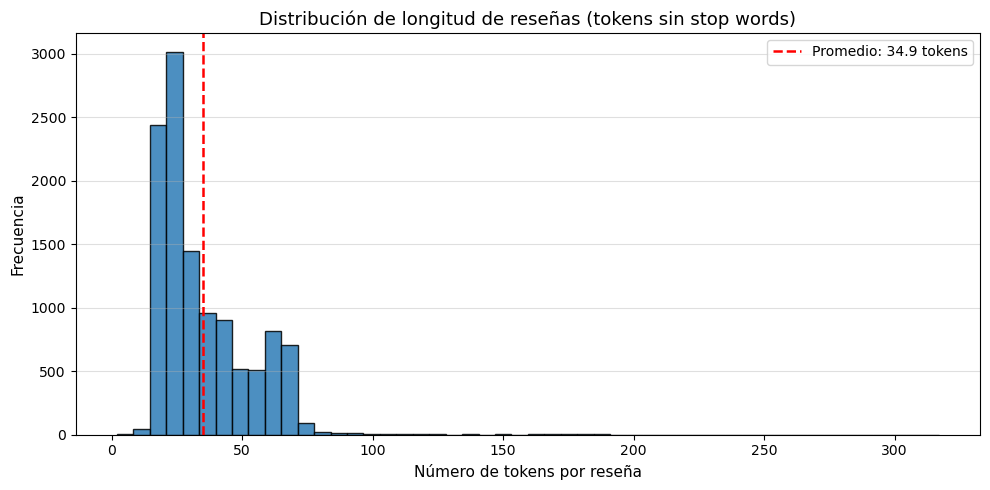

Gráfico guardado como graficos/distribucion_longitud_resenas.png


In [13]:
# ============================================================
# Histograma de longitud de reseñas (en tokens)
# ============================================================
pd_largo = df_tokens.select(size("tokens").alias("n_tokens")).toPandas()

plt.figure(figsize=(10, 5))
plt.hist(pd_largo["n_tokens"], bins=50, color="#2c7bb6", edgecolor="black", alpha=0.85)
plt.axvline(largo_promedio, color="red", linestyle="--", linewidth=1.8,
            label=f"Promedio: {largo_promedio:.1f} tokens")
plt.title("Distribución de longitud de reseñas (tokens sin stop words)", fontsize=13)
plt.xlabel("Número de tokens por reseña", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("graficos/distribucion_longitud_resenas.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/distribucion_longitud_resenas.png")

### Tarea 24 · Hapax legomena

In [14]:
# ============================================================
# Contar la frecuencia de cada palabra en todo el corpus
# ============================================================
df_frecuencias = df_tokens.select(explode("tokens").alias("token")) \
                           .groupBy("token") \
                           .count() \
                           .orderBy(desc("count"))

# Hapax legomena: palabras que aparecen exactamente una vez
df_hapax = df_frecuencias.filter(col("count") == 1)

total_palabras = df_frecuencias.count()
total_hapax    = df_hapax.count()

print("=" * 50)
print("  HAPAX LEGOMENA")
print("=" * 50)
print(f"  Vocabulario total    : {total_palabras:,}")
print(f"  Hapax legomena       : {total_hapax:,}")
print(f"  % del vocabulario    : {total_hapax/total_palabras*100:.2f}%")
print(f"  % del corpus total   : {total_hapax/total_tokens*100:.2f}%")
print("=" * 50)

print("\n--- Ejemplos de hapax legomena ---")
df_hapax.show(20, truncate=False)

  HAPAX LEGOMENA
  Vocabulario total    : 26,378
  Hapax legomena       : 13,312
  % del vocabulario    : 50.47%
  % del corpus total   : 3.31%

--- Ejemplos de hapax legomena ---
+----------+-----+
|token     |count|
+----------+-----+
|dejabas   |1    |
|chjck     |1    |
|repisita  |1    |
|anduviera |1    |
|asistiendo|1    |
|ruben     |1    |
|gatito    |1    |
|cachondo  |1    |
|optica    |1    |
|atractivas|1    |
|adjunta   |1    |
|aprieta   |1    |
|clonaban  |1    |
|ard       |1    |
|shaampo   |1    |
|paño      |1    |
|supersucia|1    |
|received  |1    |
|calamsres |1    |
|formalidad|1    |
+----------+-----+
only showing top 20 rows



**Reflexión sobre hapax legomena:**  
El 50.47% del vocabulario corresponde a hapax legomena, pero estos representan solo el 3.31% del total de tokens del corpus. Esto es tipico en reseñas de usuarios: abundan errores tipograficos (chjck, calamsres), nombres propios (ruben) y palabras compuestas (supersucia) que aparecen una sola vez.


## PARTE B · TF-IDF y análisis estadístico

### Tarea 25 · Vectorización con CountVectorizer + IDF
CountVectorizer calcula la frecuencia de cada termino (TF) y construye el vocabulario. IDF penaliza las palabras que aparecen en muchos documentos, premiando las discriminativas. El parametro minDF=2 excluye automaticamente los hapax legomena del vocabulario.

In [15]:
#============================================================
# CountVectorizer: construye el vocabulario y calcula TF
# minDF=2: excluye palabras que aparecen en menos de 2 docs
# ============================================================
cv = CountVectorizer(
    inputCol="tokens",
    outputCol="tf",
    minDF=2
)

# IDF: penaliza palabras frecuentes en muchos documentos
idf = IDF(
    inputCol="tf",
    outputCol="tfidf",
    minDocFreq=2
)

pipeline_tfidf = Pipeline(stages=[cv, idf])
modelo_tfidf   = pipeline_tfidf.fit(df_tokens)
df_tfidf       = modelo_tfidf.transform(df_tokens)

vocabulario_cv = modelo_tfidf.stages[0].vocabulary
print(f"  Pipeline TF-IDF ajustado.")
print(f"   Vocabulario final (tras minDF=2): {len(vocabulario_cv):,} palabras")

  Pipeline TF-IDF ajustado.
   Vocabulario final (tras minDF=2): 12,868 palabras


### Tarea 26 · Palabras con mayor TF-IDF promedio por clase de sentimiento

In [16]:
# ============================================================
# Promediamos sobre TODOS los documentos de la clase
# (no solo los que contienen la palabra) para evitar inflar
# palabras raras que aparecen en un solo documento
# ============================================================
def extraer_pares_tfidf(vector, vocabulario):
    pares = []
    if vector is not None:
        for idx, val in zip(vector.indices, vector.values):
            pares.append((vocabulario[idx], float(val)))
    return pares

schema_pares = ArrayType(StructType([
    StructField("palabra", StringType()),
    StructField("valor",   FloatType())
]))

vocabulario_bc = spark.sparkContext.broadcast(vocabulario_cv)

extraer_udf = F.udf(
    lambda v: extraer_pares_tfidf(v, vocabulario_bc.value),
    schema_pares
)

df_pares = df_tfidf.withColumn("pares", extraer_udf(col("tfidf"))) \
                   .select("label", explode("pares").alias("par")) \
                   .select(
                       "label",
                       col("par.palabra").alias("palabra"),
                       col("par.valor").alias("tfidf_valor")
                   )

# Total de documentos por clase para el promedio correcto
total_por_clase  = df_tfidf.groupBy("label").count().collect()
total_clase_dict = {row["label"]: row["count"] for row in total_por_clase}

mapa_sentimiento = {0: "Negativo", 1: "Positivo", 2: "Regular"}

print("--- Top 10 palabras por TF-IDF promedio por clase ---")
for clase in [0, 1, 2]:
    n_docs_clase = total_clase_dict[clase]
    print(f"\n{'='*45}")
    print(f"  {mapa_sentimiento[clase].upper()} ({n_docs_clase:,} reseñas)")
    print(f"{'='*45}")
    df_pares.filter(col("label") == clase) \
            .groupBy("palabra") \
            .agg(
                (F.sum("tfidf_valor") / n_docs_clase).alias("tfidf_promedio")
            ) \
            .withColumn("tfidf_promedio", F.round(col("tfidf_promedio"), 4)) \
            .orderBy(desc("tfidf_promedio")) \
            .show(10, truncate=False)

--- Top 10 palabras por TF-IDF promedio por clase ---

  NEGATIVO (1,553 reseñas)
+----------+--------------+
|palabra   |tfidf_promedio|
+----------+--------------+
|habitación|0.8512        |
|hotel     |0.5855        |
|mal       |0.5549        |
|noche     |0.5501        |
|baño      |0.5193        |
|reserva   |0.5054        |
|recepción |0.4971        |
|día       |0.4661        |
|dos       |0.4516        |
|cama      |0.4285        |
+----------+--------------+
only showing top 10 rows


  POSITIVO (8,529 reseñas)
+------------+--------------+
|palabra     |tfidf_promedio|
+------------+--------------+
|hotel       |0.5258        |
|bien        |0.4637        |
|personal    |0.4276        |
|habitación  |0.3956        |
|buena       |0.3891        |
|centro      |0.3836        |
|desayuno    |0.3778        |
|habitaciones|0.368         |
|excelente   |0.3675        |
|ubicación   |0.3557        |
+------------+--------------+
only showing top 10 rows


  REGULAR (1,454 reseñas)

### Tarea 27 · Comparación TF crudo vs TF-IDF y análisis por clase

In [17]:
# ============================================================
# TF crudo: palabras más frecuentes en el corpus
# TF-IDF: palabras más discriminativas por clase
# ============================================================

# Top 10 por TF crudo (frecuencia absoluta en todo el corpus)
print("--- Top 10 palabras por TF crudo (frecuencia global) ---")
df_tokens.select(explode("tokens").alias("token")) \
         .groupBy("token").count() \
         .orderBy(desc("count")) \
         .show(10, truncate=False)

# Top 10 por TF-IDF global (promedio sobre todos los documentos)
n_total = df_tfidf.count()
print("\n--- Top 10 palabras por TF-IDF promedio global ---")
df_pares.groupBy("palabra") \
        .agg(
            (F.sum("tfidf_valor") / n_total).alias("tfidf_promedio")
        ) \
        .withColumn("tfidf_promedio", F.round(col("tfidf_promedio"), 4)) \
        .orderBy(desc("tfidf_promedio")) \
        .show(10, truncate=False)

--- Top 10 palabras por TF crudo (frecuencia global) ---
+------------+-----+
|token       |count|
+------------+-----+
|hotel       |8255 |
|habitación  |5338 |
|bien        |4580 |
|personal    |3940 |
|habitaciones|3255 |
|desayuno    |2811 |
|centro      |2518 |
|buena       |2461 |
|ubicación   |2410 |
|precio      |2239 |
+------------+-----+
only showing top 10 rows


--- Top 10 palabras por TF-IDF promedio global ---
+------------+--------------+
|palabra     |tfidf_promedio|
+------------+--------------+
|hotel       |0.5422        |
|habitación  |0.4969        |
|bien        |0.4651        |
|habitaciones|0.391         |
|personal    |0.3854        |
|desayuno    |0.3608        |
|buena       |0.3575        |
|centro      |0.3487        |
|precio      |0.3366        |
|baño        |0.3364        |
+------------+--------------+
only showing top 10 rows





**Comparacion global:**  
El top 10 de TF crudo y el top 10 de TF-IDF global son casi identicos en palabras pero difieren en orden. Esto ocurre porque en un corpus tematicamente homogeneo (todas son reseñas de hoteles) las palabras mas frecuentes tambien tienden a aparecer en muchos documentos, por lo que el IDF no las penaliza tanto como lo haria en un corpus diverso. Palabras como "hotel", "habitación" y "bien" dominan ambas listas porque son centrales al dominio.

**Donde si hace diferencia el IDF — analisis por clase:**  
La verdadera utilidad del TF-IDF se ve al comparar por clase:
- **Negativo:** destacan "mal", "reserva" y "recepción" — palabras asociadas a  problemas con el servicio y gestion. Ninguna aparece en el top global.
- **Positivo:** destacan "excelente", "personal", "desayuno" y "ubicación" aspectos valorados positivamente en hoteles.
- **Regular:** destacan "bastante", "aunque" y "precio" — palabras que sugieren experiencias ni completamente buenas ni malas "Aunque" es especialmente relevante.

**Conclusion:** el TF crudo identifica el tema del corpus (hotelería); el TF-IDF por clase identifica el sentimiento. Esa es la diferencia clave entre ambas métricas.

## PARTE C · Clasificación con TF-IDF

### Tarea 28 · Variable objetivo
La variable objetivo es `label` con tres clases de sentimiento:
- `0` → Negativo (1,553 reseñas — 13.46%)
- `1` → Positivo (8,529 reseñas — 73.93%)
- `2` → Regular (1,454 reseñas — 12.60%)

El corpus ya viene etiquetado, por lo que la Tarea 29 no aplica en este caso. El modelo de Hugging Face se aplicará en la Parte D para comparar sus predicciones con las del modelo TF-IDF entrenado aqui.

El desbalance de clases (73.93% positivo) es relevante: el modelo tendera a predecir positivo por defecto.por lo tanto se balanceara antes de entrenar al modelo.

### Tarea 30 · División train/test con semilla fija

In [18]:
# ============================================================
# División train/test 80/20 con semilla fija
# ============================================================
MI_SEMILLA = 3463

df_modelo = df_tfidf.select("label", "tfidf")
df_train, df_test = df_modelo.randomSplit([0.8, 0.2], seed=MI_SEMILLA)

total_train = df_train.count()
total_test  = df_test.count()

print(f"  División completada con semilla fija = {MI_SEMILLA}")
print(f"   Train: {total_train:,} reseñas")
print(f"   Test : {total_test:,} reseñas")

print("\n--- Distribución de clases en TRAIN ---")
df_train.groupBy("label").count() \
    .withColumn("sentimiento",
        F.when(col("label")==0, "Negativo")
         .when(col("label")==1, "Positivo")
         .otherwise("Regular")) \
    .withColumn("%", F.round(col("count")/total_train*100, 2)) \
    .orderBy("label").show()

print("--- Distribución de clases en TEST ---")
df_test.groupBy("label").count() \
    .withColumn("sentimiento",
        F.when(col("label")==0, "Negativo")
         .when(col("label")==1, "Positivo")
         .otherwise("Regular")) \
    .withColumn("%", F.round(col("count")/total_test*100, 2)) \
    .orderBy("label").show()

  División completada con semilla fija = 3463
   Train: 9,240 reseñas
   Test : 2,296 reseñas

--- Distribución de clases en TRAIN ---
+-----+-----+-----------+-----+
|label|count|sentimiento|    %|
+-----+-----+-----------+-----+
|    0| 1224|   Negativo|13.25|
|    1| 6837|   Positivo|73.99|
|    2| 1179|    Regular|12.76|
+-----+-----+-----------+-----+

--- Distribución de clases en TEST ---
+-----+-----+-----------+-----+
|label|count|sentimiento|    %|
+-----+-----+-----------+-----+
|    0|  329|   Negativo|14.33|
|    1| 1692|   Positivo|73.69|
|    2|  275|    Regular|11.98|
+-----+-----+-----------+-----+



In [19]:
# ============================================================
# Balanceo por weightCol 
# Se calculan pesos inversamente proporcionales a la frecuencia
# de cada clase para que el modelo no ignore Negativo y Regular
# ============================================================
n_clases = 3

conteos_train = df_train.groupBy("label").count().collect()
pesos_dict    = {row["label"]: total_train / (n_clases * row["count"])
                 for row in conteos_train}

print("--- Pesos asignados por clase ---")
for clase, peso in sorted(pesos_dict.items()):
    print(f"  {mapa_sentimiento[clase]:<12} → peso: {peso:.4f}")

# Agregar columna de pesos al train
df_train_w = df_train.withColumn(
    "weight",
    F.when(col("label")==0, pesos_dict[0])
     .when(col("label")==1, pesos_dict[1])
     .otherwise(pesos_dict[2])
)

print(f"\n Pesos aplicados a df_train_w.")

--- Pesos asignados por clase ---
  Negativo     → peso: 2.5163
  Positivo     → peso: 0.4505
  Regular      → peso: 2.6124

 Pesos aplicados a df_train_w.


### Tarea 31 · Regresión Logística sobre vectores TF-IDF

In [20]:
# ============================================================
# weightCol="weight": penaliza mas los errores en clases minoritarias
# ============================================================
lr_tfidf = LogisticRegression(
    labelCol="label",
    featuresCol="tfidf",
    weightCol="weight",
    family="multinomial",
    maxIter=20,
    regParam=0.01,
    elasticNetParam=0.0
)

modelo_lr_tfidf = lr_tfidf.fit(df_train_w)
pred_lr_tfidf   = modelo_lr_tfidf.transform(df_test)

print("Modelo de Regresión Logística entrenado sobre TF-IDF con balanceo por pesos.")

Modelo de Regresión Logística entrenado sobre TF-IDF con balanceo por pesos.


### Tarea 32 · Métricas: accuracy, F1 y matriz de confusión

  MÉTRICAS — TF-IDF + Regresión Logística
  Accuracy           : 0.8193
  Precision (pond.)  : 0.8224
  Recall    (pond.)  : 0.8193
  F1-Score  (pond.)  : 0.8202


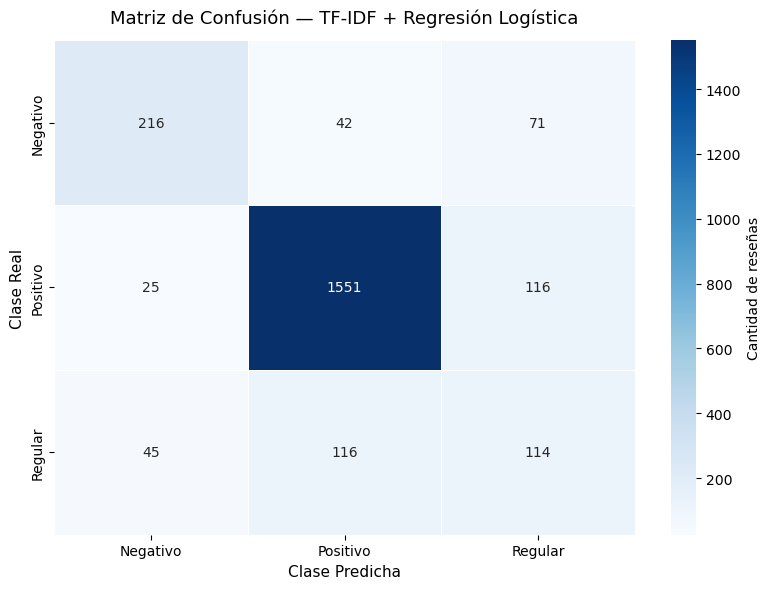

Gráfico guardado como graficos/matriz_confusion_tfidf_lr.png


In [21]:
# ============================================================
# Evaluacion del modelo TF-IDF + Regresión Logística
# ============================================================
evaluador = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

accuracy  = evaluador.evaluate(pred_lr_tfidf, {evaluador.metricName: "accuracy"})
f1        = evaluador.evaluate(pred_lr_tfidf, {evaluador.metricName: "f1"})
precision = evaluador.evaluate(pred_lr_tfidf, {evaluador.metricName: "weightedPrecision"})
recall    = evaluador.evaluate(pred_lr_tfidf, {evaluador.metricName: "weightedRecall"})

print("=" * 52)
print("  MÉTRICAS — TF-IDF + Regresión Logística")
print("=" * 52)
print(f"  Accuracy           : {accuracy:.4f}")
print(f"  Precision (pond.)  : {precision:.4f}")
print(f"  Recall    (pond.)  : {recall:.4f}")
print(f"  F1-Score  (pond.)  : {f1:.4f}")
print("=" * 52)

# Matriz de confusión
mapa_clases_nlp = {0.0: "Negativo", 1.0: "Positivo", 2.0: "Regular"}
pd_conf_nlp = pred_lr_tfidf.select("label", "prediction").toPandas()
pd_conf_nlp["real"]     = pd_conf_nlp["label"].map({0: "Negativo", 1: "Positivo", 2: "Regular"})
pd_conf_nlp["predicho"] = pd_conf_nlp["prediction"].map(mapa_clases_nlp)

orden_nlp = ["Negativo", "Positivo", "Regular"]
matriz_nlp = pd.crosstab(
    pd_conf_nlp["real"],
    pd_conf_nlp["predicho"],
    rownames=["Real"],
    colnames=["Predicho"]
).reindex(index=orden_nlp, columns=orden_nlp, fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_nlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de reseñas"}
)
plt.title("Matriz de Confusión — TF-IDF + Regresión Logística", fontsize=13, pad=12)
plt.ylabel("Clase Real", fontsize=11)
plt.xlabel("Clase Predicha", fontsize=11)
plt.tight_layout()
plt.savefig("graficos/matriz_confusion_tfidf_lr.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/matriz_confusion_tfidf_lr.png")

### Tarea 33 · Coeficientes del modelo: palabras que predicen cada clase

In [22]:
# ============================================================
# Cada clase tiene tokens que ayudan a predecir cada clase
# ============================================================
coeficientes = modelo_lr_tfidf.coefficientMatrix.toArray()

print("--- Top 10 palabras que predicen cada clase ---")
for clase in [0, 1, 2]:
    coefs_clase  = coeficientes[clase]
    top_indices  = np.argsort(coefs_clase)[::-1][:10]
    print(f"\n{'='*45}")
    print(f"  {mapa_sentimiento[clase].upper()}")
    print(f"{'='*45}")
    for idx in top_indices:
        print(f"  {vocabulario_cv[idx]:<20} {coefs_clase[idx]:.4f}")

--- Top 10 palabras que predicen cada clase ---

  NEGATIVO
  critica              0.4139
  sufrió               0.3697
  publican             0.3680
  pobremente           0.3425
  destartalada         0.3179
  aconsejándonos       0.3151
  rustico              0.3129
  cristóbal            0.3020
  franco               0.2975
  mayoria              0.2928

  POSITIVO
  parkig               0.6304
  visitáis             0.6127
  cento                0.4880
  motor                0.4470
  armando              0.4438
  pedid                0.4100
  cumplido             0.3959
  lad                  0.3955
  cita                 0.3946
  kilometros           0.3921

  REGULAR
  merche               0.3741
  calentitas           0.3724
  wl                   0.3500
  dudarán              0.3374
  desplazarse          0.3243
  integrados           0.3093
  meterse              0.3049
  cuidaran             0.3004
  superagradable       0.3003
  mantenerse           0.2997


**Interpretación de los coeficientes:**  
Las palabras con mayor coeficiente por clase tienden a ser terminos muy especificos y poco frecuentes que aparecen casi exclusivamente en reseñas de una sola clase. Por ejemplo, "critica" y "sufrió" predicen fuertemente Negativo por ser terminos usados en reseñas muy negativas; "centro" aparece en Positivo probablemente refiriendose a una buena ubicacion del lugar. existe una limitacion conocida de la Regresion Logistica sobre TF-IDF: los coeficientes mas altos no siempre corresponden a las palabras mas intuitivas, sino a las mas discriminativas estadisticamente.Por lo tanto, para interpretacion mas intuitiva del sentimiento, el modelo de Hugging Face (Parte D) es mas apropiado.

## PARTE D · Modelo pre-entrenado de Hugging Face

### Tarea 34 · Cargar el modelo pre-entrenado
Se usa `pysentimiento/robertuito-sentiment-analysis`, modelo entrenado especificamente sobre tweets en español latinoamericano. 

Clasifica en tres clases:
- `POS` → Positivo
- `NEG` → Negativo  
- `NEU` → Neutro/Regular

Es el modelo mas apropiado para reseñas en español porque fue entrenado con texto informal en español, similar al lenguaje usado en reseñas de hoteles.

In [23]:
# ============================================================
# transformers: librería principal de modelos pre-entrenados
# pysentimiento: wrapper simplificado para análisis de sentimiento
# ============================================================
# Cargar el analizador de sentimiento en español
analizador_hf = create_analyzer(task="sentiment", lang="es")

print("Modelo pysentimiento/robertuito-sentiment-analysis cargado.")
print(f"   Clases disponibles: POS, NEG, NEU")

# Probar con un ejemplo rápido
ejemplo = "El hotel fue excelente, el personal muy amable."
resultado = analizador_hf.predict(ejemplo)
print(f"\nPrueba rápida:")
print(f"  Texto    : {ejemplo}")
print(f"  Predicción: {resultado.output} (scores: {resultado.probas})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo pysentimiento/robertuito-sentiment-analysis cargado.
   Clases disponibles: POS, NEG, NEU

Prueba rápida:
  Texto    : El hotel fue excelente, el personal muy amable.
  Predicción: POS (scores: {'NEG': 0.003778940998017788, 'NEU': 0.020533498376607895, 'POS': 0.9756875038146973})


### Tarea 35 · Aplicar el modelo a todo el corpus

In [24]:
# ============================================================
# Aplicar Hugging Face a todo el corpus
# Trabajamos sobre pandas porque HF no corre nativamente en Spark
# Convertimos df_tfidf a pandas solo con las columnas necesarias
# ============================================================
pd_corpus = df_tfidf.select("label", "review_text").toPandas()

print(f"Aplicando modelo HF a {len(pd_corpus):,} reseñas...")
print("(Esto puede tardar varios minutos)")

def predecir_hf(texto):
    try:
        resultado = analizador_hf.predict(str(texto)[:512])
        return resultado.output
    except Exception:
        return "NEU"

pd_corpus["sentimiento_hf"] = pd_corpus["review_text"].apply(predecir_hf)

# Mapear etiquetas HF al mismo formato numérico que usamos
# NEG=0, POS=1, NEU=2 — consistente con nuestro label remapeado
mapa_hf = {"NEG": 0, "POS": 1, "NEU": 2}
pd_corpus["label_hf"] = pd_corpus["sentimiento_hf"].map(mapa_hf)

print(f"\n Modelo HF aplicado a {len(pd_corpus):,} reseñas.")
print("\n--- Distribución de predicciones HF ---")
print(pd_corpus["sentimiento_hf"].value_counts())


Aplicando modelo HF a 11,536 reseñas...
(Esto puede tardar varios minutos)

 Modelo HF aplicado a 11,536 reseñas.

--- Distribución de predicciones HF ---
sentimiento_hf
POS    8909
NEG    1909
NEU     718
Name: count, dtype: int64


### Tarea 36 · Comparación HF vs TF-IDF

  MÉTRICAS — Hugging Face (robertuito)
  Accuracy           : 0.8288
  F1-Score (pond.)   : 0.8098

  COMPARACIÓN FINAL: TF-IDF vs Hugging Face
  Métrica                    TF-IDF           HF
----------------------------------------------------
  Accuracy                   0.8193       0.8288
  F1 ponderado               0.8202       0.8098


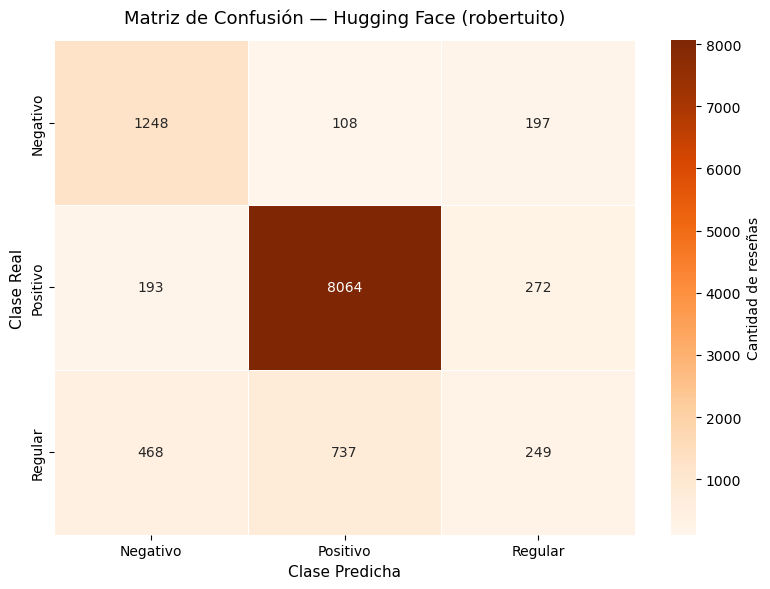

Gráfico guardado como graficos/matriz_confusion_hf.png


In [25]:
# ============================================================
# Métricas del modelo Hugging Face
# ============================================================
# Filtrar filas donde HF pudo predecir
pd_valido = pd_corpus.dropna(subset=["label_hf"])

y_real = pd_valido["label"].astype(int)
y_hf   = pd_valido["label_hf"].astype(int)

acc_hf = accuracy_score(y_real, y_hf)
f1_hf  = f1_score(y_real, y_hf, average="weighted")

print("=" * 52)
print("  MÉTRICAS — Hugging Face (robertuito)")
print("=" * 52)
print(f"  Accuracy           : {acc_hf:.4f}")
print(f"  F1-Score (pond.)   : {f1_hf:.4f}")
print("=" * 52)

# Comparación directa con TF-IDF
print("\n" + "=" * 52)
print("  COMPARACIÓN FINAL: TF-IDF vs Hugging Face")
print("=" * 52)
print(f"  {'Métrica':<20} {'TF-IDF':>12} {'HF':>12}")
print("-" * 52)
print(f"  {'Accuracy':<20} {accuracy:>12.4f} {acc_hf:>12.4f}")
print(f"  {'F1 ponderado':<20} {f1:>12.4f} {f1_hf:>12.4f}")
print("=" * 52)

# Matriz de confusión HF
matriz_hf = confusion_matrix(y_real, y_hf)
orden_nlp  = ["Negativo", "Positivo", "Regular"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.DataFrame(matriz_hf, index=orden_nlp, columns=orden_nlp),
    annot=True,
    fmt="d",
    cmap="Oranges",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de reseñas"}
)
plt.title("Matriz de Confusión — Hugging Face (robertuito)", fontsize=13, pad=12)
plt.ylabel("Clase Real", fontsize=11)
plt.xlabel("Clase Predicha", fontsize=11)
plt.tight_layout()
plt.savefig("graficos/matriz_confusion_hf.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/matriz_confusion_hf.png")


### Tarea 37 · Casos difíciles — sarcasmo, ambigüedad y negaciones

In [26]:
# ============================================================
# Probar ambos modelos con casos difíciles
# Adaptados al contexto de reseñas de hoteles en español
# ============================================================
casos_dificiles = [
    ("Sarcasmo",    "Claro que sí, esperar dos horas para el check-in es lo máximo del servicio."),
    ("Negación",    "No estuvo nada mal, la verdad no me puedo quejar de nada."),
    ("Ambigüedad",  "El hotel no estaba mal del todo, pero tampoco era para escribir un poema."),
    ("Sarcasmo",    "Las cañerías sonaban toda la noche, muy relajante para dormir."),
    ("Negación",    "No fue el peor hotel en el que he estado, algo es algo."),
    ("Ambigüedad",  "El desayuno era correcto, ni para celebrar ni para llorar.")
]

# Obtener predicciones de TF-IDF para los casos difíciles
df_casos = spark.createDataFrame(
    [(i, texto, tipo, 0) for i, (tipo, texto) in enumerate(casos_dificiles)],
    ["id", "review_text", "tipo", "label"]
)

# Aplicar pipeline completo de tokenización y TF-IDF
df_casos_tok   = tokenizer.transform(df_casos)
df_casos_tok   = remover.transform(df_casos_tok)
df_casos_tfidf = modelo_tfidf.transform(df_casos_tok)
pred_casos_lr  = modelo_lr_tfidf.transform(df_casos_tfidf)

preds_tfidf = pred_casos_lr.select("id", "prediction") \
                            .orderBy("id").collect()
mapa_pred   = {0.0: "NEG", 1.0: "POS", 2.0: "NEU"}

# Imprimir tabla comparativa
print(f"{'#':<3} {'Tipo':<12} {'Texto':<55} {'HF':<6} {'TF-IDF':<6}")
print("=" * 85)
for i, (tipo, texto) in enumerate(casos_dificiles):
    pred_hf    = analizador_hf.predict(texto).output
    pred_tfidf = mapa_pred.get(preds_tfidf[i]["prediction"], "?")
    texto_corto = texto[:52] + "..." if len(texto) > 55 else texto
    print(f"{i+1:<3} {tipo:<12} {texto_corto:<55} {pred_hf:<6} {pred_tfidf:<6}")


#   Tipo         Texto                                                   HF     TF-IDF
1   Sarcasmo     Claro que sí, esperar dos horas para el check-in es ... POS    POS   
2   Negación     No estuvo nada mal, la verdad no me puedo quejar de ... POS    POS   
3   Ambigüedad   El hotel no estaba mal del todo, pero tampoco era pa... NEU    NEU   
4   Sarcasmo     Las cañerías sonaban toda la noche, muy relajante pa... POS    NEU   
5   Negación     No fue el peor hotel en el que he estado, algo es algo. NEU    POS   
6   Ambigüedad   El desayuno era correcto, ni para celebrar ni para l... NEU    POS   


### Tarea 38 · Conclusión: ¿qué enfoque recomendarías para producción?

Los resultados son muy similares. HF tiene mayor accuracy (0.8288 vs 0.8193) pero TF-IDF supera en F1 ponderado (0.8202 vs 0.8098). Esta diferencia se explica por el desbalance del corpus: HF clasifica mejor la clase mayoritaria (Positivo: 8,064 correctos) pero falla mas en Regular.

**Analisis de casos dificiles:**
Ambos modelos muestran limitaciones importantes en casos dificiles:

- **Sarcasmo (caso 1):** ambos predicen POS para *"esperar dos horas para el check-in es lo máximo"* — ninguno detecta la ironia.
- **Sarcasmo (caso 4):** HF predice POS para *"las cañerías sonaban toda la noche, muy relajante"* mientras TF-IDF se acerca mas con un NEU. Aqui TF-IDF supera a HF.
- **Negacion (caso 5):** HF acierta con NEU para *"no fue el peor hotel"* mientras TF-IDF predice POS incorrectamente.
- **Ambigüedad (caso 6):** HF acierta con NEU para *"ni para celebrar ni para llorar"* mientras TF-IDF predice POS incorrectamente.

**Recomendacion para produccion: Hugging Face limitaciones**

A pesar de que los numeros globales son similares, HF maneja mejor las negaciones y la ambigüedad (casos 5 y 6), que son frecuentes en reseñas reales. TF-IDF sorprendentemente detecto mejor el sarcasmo en el caso 4, pero esto puede ser un caso atipico.

Para produccion se recomendaria HF por tres razones:
1. Generaliza mejor a reseñas con vocabulario nuevo sin reentrenar.
2. Captura contexto y negaciones mejor que el en TF-IDF.

**Limitacion honesta:** ninguno de los dos modelos detecta sarcasmo de forma confiable. Para un sistema en produccion se recomendaria un modelo especializado en deteccion de sarcasmo.

- **Escalabilidad:** TF-IDF requiere reentrenar el modelo completo si el vocabulario cambia. Hugging Face generaliza a textos nuevos sin reentrenamiento y funciona de manera optima.

**Cuando usar TF-IDF:** cuando los recursos computacionales son limitados, el corpus es grande y el texto es formal y predecible. TF-IDF es mas rapido y liviano que Hugging Face.

## Conclusiones del Bloque 3

**Conclusion 1 — Preparacion y estadistica del corpus (Parte A):**  
El corpus final quedó con 11,536 reseñas unicas en español tras eliminar 4,815 duplicados (29.45%) y 4 reseñas en ruso que el tokenizador no pudo procesar. El vocabulario resultante fue de 12,868 palabras únicas (tras minDF=2), con un TTR de 0.044 el cual se considera bajo pero esperado para un corpus tematicamente homogeneo de reseñas hoteleras. El 50.47% del vocabulario correspondió a hapax legomena, eliminados automáticamente por el CountVectorizer sin necesidad de filtrado manual.

**Conclusion 2 — TF-IDF y clasificacion (Partes B y C):**  
El analisis TF-IDF por clase revelo patrones semanticos claros: la clase Negativo se asocia a palabras como "critica", "sufrió" y "publicsn" (TF-IDF promedio de 0.41, 0.36 y 0.36 respectivamente), mientras Positivo destaca "parkig", "visitáis" y "centro" (0.63, 0.61 y 0.48). La Regresion Logistica entrenada sobre los vectores TF-IDF con balanceo por pesos alcanzo un F1 ponderado de 0.8202 y accuracy de 0.8193.

**Conclusion 3 — Comparacion TF-IDF vs Hugging Face (Parte D):**  
El modelo pre-entrenado robertuito alcanzo accuracy de 0.8288 vs 0.8193 de TF-IDF, pero un F1 ponderado ligeramente inferior (0.8098 vs 0.8202). La diferencia mas relevante no es cuantitativa sino cualitativa: HF maneja mejor negaciones y ambigüedad (casos 5 y 6 de los casos dificiles), mientras que ninguno de los dos detecta sarcasmo de forma confiable. Para produccion se recomienda HF por su capacidad de generalizar a vocabulario nuevo sin reentrenamiento, usando TF-IDF como alternativa cuando los recursos computacionales sean limitados.